In [ ]:
# Manipulação de dados
import pandas as pd

# Divide os dados em treino e teste
from sklearn.model_selection import train_test_split

# Converte textos em números
from sklearn.preprocessing import OneHotEncoder

# Aplica transformações nas colunas
from sklearn.compose import ColumnTransformer

# Modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
#Carregando o dataset

df = pd.read_csv("/content/Vendasloja - Vendasloja.csv")


In [ ]:
#carregar as primeiras linhas

df.head()

,ID,Produto,Categoria,Qtd,Preco,Desconto,Cidade,ClienteVIP,Frete,FormaPagamento,DiaSemana,Lucro
0,1,Mouse,Periférico,1.0,3500,10,Belém,Sim,35,Pix,Sab,590.0
1,2,Cadeira Gamer,Móveis,2.0,1800,15,Manaus,Sim,20,Cartão,Ter,604.0
2,3,Cadeira Gamer,Móveis,10.0,80,5,Santarém,Não,35,Boleto,Sex,105.0
3,4,SSD,Hardware,1.0,150,15,Boa Vista,Não,35,Cartão,Qua,NaN
4,5,Mouse,Periférico,2.0,650,0,Boa Vista,Não,100,Dinheiro,Seg,134.0


In [ ]:
 #Quantidade de linhas e colunas
df.shape

(250, 12)

In [ ]:
#Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              250 non-null    int64  
 1   Produto         250 non-null    object 
 2   Categoria       250 non-null    object 
 3   Qtd             240 non-null    float64
 4   Preco           250 non-null    int64  
 5   Desconto        250 non-null    int64  
 6   Cidade          240 non-null    object 
 7   ClienteVIP      250 non-null    object 
 8   Frete           250 non-null    int64  
 9   FormaPagamento  250 non-null    object 
 10  DiaSemana       250 non-null    object 
 11  Lucro           240 non-null    float64
dtypes: float64(2), int64(4), object(6)
memory usage: 23.6+ KB


In [ ]:
#Estatísticas descritivas
df.describe()


,ID,Qtd,Preco,Desconto,Frete,Lucro
count,250.000000,240.000000,250.00000,250.000000,250.000000,240.000000
mean,116.300000,5.383333,853.60000,7.120000,55.280000,772.969375
std,71.076137,2.985834,862.88849,5.552379,27.424991,1004.427110
min,1.000000,1.000000,80.00000,0.000000,20.000000,-72.000000
25%,53.250000,3.000000,167.50000,0.000000,35.000000,96.550000
50%,115.500000,5.000000,550.00000,7.500000,50.000000,377.750000
75%,177.750000,8.000000,1200.00000,10.000000,70.000000,1065.000000
max,240.000000,10.000000,3500.00000,15.000000,100.000000,5477.500000


In [ ]:
#identificar valores ausentes

df.isnull().sum()

,0
ID,0
Produto,0
Categoria,0
Qtd,10
Preco,0
Desconto,0
Cidade,10
ClienteVIP,0
Frete,0
FormaPagamento,0


Tratar os valores ausentes

In [ ]:
#Substituindo os valores numéricos pela mediana.
df["Qtd"] = df["Qtd"].fillna(df["Qtd"].median())

df["Lucro"] = df["Lucro"].fillna(df["Lucro"].median())

In [ ]:
#Substituindo a coluna categórica pela moda.
df["Cidade"] = df["Cidade"].fillna(
df["Cidade"].mode()[0]
)

#Conferindo novamente.
df.isnull().sum()

,0
ID,0
Produto,0
Categoria,0
Qtd,0
Preco,0
Desconto,0
Cidade,0
ClienteVIP,0
Frete,0
FormaPagamento,0


In [ ]:
#Separando X e y
# Variável alvo
y = df["Lucro"]

# Variáveis de entrada
X = df.drop(columns=["ID","Lucro"])

In [ ]:
#Identificando colunas categóricas
categoricas = [
    "Produto",
    "Categoria",
    "Cidade",
    "ClienteVIP",
    "FormaPagamento",
    "DiaSemana"]

In [ ]:
#Criando o One Hot Encoder
#trasnforma as variáveis categoricas em numéricas
preprocessador = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        )
    ],
    remainder="passthrough"
)

In [ ]:
#Aplicando a transformação

X = preprocessador.fit_transform(X)

In [ ]:
#Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [ ]:
#Criando o modelo
modelo = LinearRegression()

In [ ]:
#Treinando o modelo
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Fazendo previsões
y_pred = modelo.predict(X_test)

In [ ]:
#Avaliando o modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

MAE: 390.89
R²: 0.82


In [ ]:
#Comparando valores reais e previstos
resultado = pd.DataFrame({
    "Lucro Real": y_test,
    "Lucro Previsto": y_pred
})

resultado.head(10)

,Lucro Real,Lucro Previsto
142,769.00,598.920489
6,23.00,-422.838477
97,108.40,346.573928
60,87.00,191.340835
112,94.60,446.871953
181,478.00,466.707135
197,34.75,-394.951997
184,212.00,299.558746
9,346.60,832.902952
104,5285.00,3730.964438


Parte 2 – Comparando Modelos: Árvore de Decisão
Na primeira parte da aula utilizamos a Regressão Linear para prever o lucro
das vendas. Agora vamos responder à mesma pergunta de negócio utilizando
outro algoritmo: Árvore de Decisão. Ao final, compararemos os resultados dos
dois modelos utilizando as métricas MAE e R².

In [ ]:
#   Criar o modelo de Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor
modelo_arvore = DecisionTreeRegressor(random_state=42)

In [ ]:
#Treinando o modelo
modelo_arvore.fit(
X_train,
y_train
)

DecisionTreeRegressor(random_state=42)

In [ ]:
#Fazendo previsões

y_pred_arvore = modelo_arvore.predict(
X_test
)


In [ ]:
#Avaliando o modelo

mae_arvore = mean_absolute_error(
y_test,
y_pred_arvore
)

r2_arvore = r2_score(
y_test,
y_pred_arvore
)

print(f"MAE: {mae_arvore:.2f}")
print(f"R²: {r2_arvore:.2f}")

MAE: 190.18
R²: 0.87


In [ ]:
#Comparando valores reais e previstos
resultado_arvore = pd.DataFrame({
"Lucro Real": y_test,
"Lucro Previsto": y_pred_arvore
})

resultado_arvore.head(10)

,Lucro Real,Lucro Previsto
142,769.00,806.25
6,23.00,46.00
97,108.40,38.80
60,87.00,113.75
112,94.60,103.80
181,478.00,415.00
197,34.75,5.80
184,212.00,265.00
9,346.60,235.00
104,5285.00,3350.00


In [ ]:
#Comparação dos modelos

#Agora juntamos os resultados da Regressão Linear e da Árvore de
comparacao = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Árvore de Decisão"],
    "MAE": [mae, mae_arvore],
    "R²": [r2, r2_arvore]
})

comparacao

,Modelo,MAE,R²
0,Regressão Linear,390.885092,0.822589
1,Árvore de Decisão,190.178000,0.867948


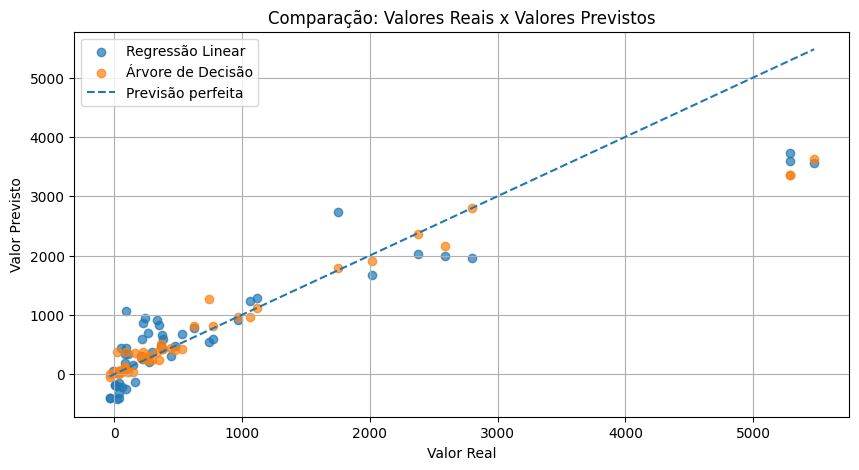

In [ ]:
import matplotlib.pyplot as plt

# Gráfico: valores reais x valores previstos

plt.figure(figsize=(10,5))

# Regressão Linear
plt.scatter(y_test, y_pred,
            label="Regressão Linear", alpha=0.7)

# Árvore de Decisão
plt.scatter(y_test, y_pred_arvore,
            label="Árvore de Decisão", alpha=0.7)

# Linha ideal (previsão perfeita)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--",
         label="Previsão perfeita")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")

plt.title("Comparação: Valores Reais x Valores Previstos")
plt.legend()
plt.grid(True)

plt.show()

Conclusão

Este projeto teve como objetivo desenvolver e comparar modelos de aprendizado de máquina capazes de prever o lucro de uma empresa a partir de diferentes características presentes no conjunto de dados. Para isso, foi seguido um fluxo completo de desenvolvimento de um modelo preditivo, desde o tratamento dos dados até a avaliação dos resultados.

Na primeira etapa, foi realizada a separação das variáveis independentes (X) e da variável alvo (Lucro), permitindo que os algoritmos identificassem corretamente quais informações seriam utilizadas para realizar as previsões. Em seguida, as variáveis categóricas, como produto, categoria, cidade, cliente VIP, forma de pagamento e dia da semana, foram transformadas em variáveis numéricas por meio da técnica One-Hot Encoding, utilizando o ColumnTransformer. Esse processo foi essencial para que os algoritmos de regressão pudessem interpretar corretamente essas informações durante o treinamento.

Após o pré-processamento, o conjunto de dados foi dividido em dois grupos: 80% para treinamento e 20% para teste. Essa divisão permitiu treinar os modelos utilizando a maior parte dos dados e avaliar seu desempenho em dados nunca vistos, reduzindo o risco de superestimação dos resultados.

Na etapa de modelagem, foram treinados dois algoritmos de regressão: a Regressão Linear e a Árvore de Decisão para Regressão. Ambos os modelos foram avaliados por meio das métricas MAE (Erro Absoluto Médio), que mede o erro médio das previsões, e R² (Coeficiente de Determinação), que indica o quanto o modelo consegue explicar a variação dos dados.

Os resultados mostraram que a Regressão Linear obteve um MAE de 390,89 e um R² de 0,82, apresentando um bom desempenho na previsão do lucro. Entretanto, o modelo de Árvore de Decisão apresentou resultados superiores, alcançando um MAE de 190,18 e um R² de 0,87, o que significa que suas previsões ficaram mais próximas dos valores reais e que o modelo conseguiu explicar uma parcela maior da variação do lucro.

Por fim, foi construída uma visualização gráfica comparando os valores reais e previstos pelos dois modelos. Essa análise visual confirmou o melhor desempenho da Árvore de Decisão, demonstrando que suas previsões se aproximaram mais da linha de previsão ideal.

Dessa forma, conclui-se que todas as etapas do projeto — desde o pré-processamento dos dados, codificação das variáveis categóricas, divisão dos dados, treinamento dos modelos, avaliação por métricas e análise gráfica — foram fundamentais para a construção de um modelo preditivo confiável. Entre os modelos testados, a Árvore de Decisão apresentou o melhor desempenho, tornando-se a opção mais adequada para estimar o lucro nesse conjunto de dados. Além disso, o projeto demonstrou a importância da preparação correta dos dados e da comparação entre diferentes algoritmos para identificar a solução mais eficiente para problemas de previsão, contribuindo para uma tomada de decisão mais precisa e baseada em dados.